# Constitutive Expression
Interested in DEGs identified in oysters sampled after phase 1, and how the expression of those genes change in oysters from phase 2 (aka ***consistitutve expression***: expresssion that remains high/low into later life)

## 0. load libraries

In [2]:
library(tidyverse)
library(plyr)

## 1. read in CSVs

first, want to pull out genes with differential expression from oysters sampled after phase 1.

### after phase 1 oyster samples
DEGs only

In [3]:
# get list of files
files <- list.files(
    path = '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/deseq_res_files/DEGs/',
    full.names = TRUE
    )

names(files) <- gsub("^DEG_", "", tools::file_path_sans_ext(basename(files)))
deg_list <- lapply(files, read.csv)
names(deg_list)
head(deg_list$b_c)

[1] "b_c" "h_b" "h_c" "h_w" "w_b" "w_c"

,X,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,svalue,pair,DEG_group
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
1,LOC111119645,653.22102,-5.020538,2.441757,-4.024549,5.708460e-05,1.196733e-02,2.961309e-02,C vs. B,C
2,LOC111111234,734.07909,-1.798884,1.216529,-3.763521,1.675379e-04,2.586952e-02,6.637397e-02,C vs. B,C
3,LOC111104630,30.39451,1.701065,1.638795,3.500313,4.647117e-04,4.910747e-02,1.288707e-01,C vs. B,B
4,LOC111129171,35.65903,-20.575402,4.241105,-5.271934,1.349937e-07,8.337208e-05,2.209650e-04,C vs. B,C
5,LOC111121183,21.46042,21.131265,3.106873,6.986352,2.821259e-12,5.808033e-09,1.007325e-08,C vs. B,B
6,LOC111111721,37.95811,-4.710274,1.156190,-4.669312,3.022105e-06,1.278392e-03,1.662824e-03,C vs. B,C


and then just in case I want vst expression for these oysters later:

In [4]:
p1.vst <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/deseq_res_files/all_genes/p1.both_v_cont.csv') %>%
select(-1, -3:-9)
head(p1.vst)

,Gene,B1_Nu_O03,B2_Nu_O12,B4_Nu_O32,B5_Nu_O36,B6_Nu_O47,C1_Nu_W01,C1_Nu_W05,C2_Nu_W15,C3_Nu_W21,⋯,H3_Nu_B18,H4_Nu_B28,H5_Nu_B35,H6_Nu_B45,W1_Nu_G02,W2_Nu_G15,W3_Nu_G21,W4_Nu_G27,W6_Nu_G41,W6_Nu_G45
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC111116054,0.8524235,15.240013,10.874293,12.37254,1.041203,13.946695,2.142553,1.049389,1.535909,⋯,20.387079,27.630883,15.36239,0.000000,2.219590,27.10004,11.138883,8.232622,0.9892009,2.494458
2,LOC111126949,555.7800963,498.157926,371.398937,1617.42906,634.092462,457.625927,1152.693402,567.719691,434.662227,⋯,574.660783,579.295752,762.99887,516.689045,1007.693786,1455.15442,250.624864,372.297452,486.6868213,411.585532
3,LOC111110729,178.1565033,168.592644,173.152207,173.21563,191.581302,129.006928,154.263801,168.951701,119.032942,⋯,173.290170,143.871149,226.33926,187.529273,170.908417,75.40881,84.469861,128.063006,116.7257011,143.431322
4,LOC111112434,5.9669642,1.905002,8.364841,21.37076,18.741649,9.588353,18.211699,22.037178,13.823180,⋯,7.645155,5.716734,25.60399,6.556968,17.756719,0.00000,9.282402,6.403150,21.7624188,0.000000
5,LOC111120752,499.5201479,397.192840,324.555827,227.20492,343.596901,739.174830,252.821229,163.704754,536.800171,⋯,354.225494,386.832361,288.81300,301.620509,318.141210,539.64431,862.335179,396.080582,614.2937318,313.054450
6,LOC111128944,0.0000000,0.000000,0.000000,0.00000,0.000000,0.000000,2.142553,4.197558,0.000000,⋯,17.838694,1.905578,0.00000,0.000000,1.479727,0.00000,3.712961,0.000000,0.0000000,1.247229


then want to pull out the expression of oysters sampled after phase 2

### after phase 2 oyster samples
I think for this I only need vst ... (and all genes, not just DEGs)

In [5]:
p2.vst <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/deseq_res_files/all_genes/bc_hc.csv') %>%
select(-2:-8) # remove the deseq junk
head(p2.vst)

,Gene,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,B3_B4_O41,B3_C3_O30,B3_C6_O66,B3_H4_O41,B3_W1_O06,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC111116054,1.875059,5.965799,9.44740,7.830485,0.00000,11.75544,14.436329,9.311552,7.673523,⋯,4.336105,2.452846,11.19491,2.006592,7.359253,5.277065,2.300668,21.05700,1.075999,0.0000
2,LOC111126949,829.713451,474.281013,617.85999,509.851567,453.26645,419.66928,325.473593,558.693109,621.555373,⋯,230.897604,544.531781,506.25864,742.439160,650.373981,428.497663,480.839693,469.90350,302.355713,636.4963
3,LOC111110729,60.001877,92.469883,59.51862,87.005387,87.87819,115.20333,154.206239,187.265653,97.563365,⋯,128.999131,62.138762,87.07151,149.491128,111.308701,121.372491,144.942108,119.69240,136.651870,226.3334
4,LOC111112434,10.312823,1.988600,0.00000,1.740108,13.87550,17.63316,6.561968,37.246207,1.096218,⋯,6.504158,0.000000,13.68267,6.019777,3.679626,0.000000,2.300668,17.73221,8.607992,0.0000
5,LOC111120752,337.510556,334.084739,402.45926,305.388908,272.88491,326.80129,499.365735,385.912092,202.800254,⋯,421.686235,286.165350,446.55246,346.137176,402.919100,293.404804,330.145914,461.03739,358.307660,456.9172
6,LOC111128944,0.000000,0.000000,0.00000,0.000000,0.00000,0.00000,0.000000,0.000000,0.000000,⋯,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.0000


#### combine vst dfs

In [6]:
vst_all <- merge(p1.vst, p2.vst, by = 'Gene')
dim(vst_all)
head(vst_all)

[1] 35466   118

,Gene,B1_Nu_O03,B2_Nu_O12,B4_Nu_O32,B5_Nu_O36,B6_Nu_O47,C1_Nu_W01,C1_Nu_W05,C2_Nu_W15,C3_Nu_W21,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,ATP6,1.615897e+05,2.266171e+05,245642.7547,152223.9196,164486.08365,244606.72357,2.033175e+05,242377.48061,260844.18163,⋯,258362.49506,166071.5641,198001.85929,239161.7260,126553.39366,231569.21375,181313.37505,197802.77326,137557.86138,184733.76778
2,COX1,5.507124e+05,1.138566e+06,864134.0729,526061.4901,742432.73012,881107.72891,1.018095e+06,830332.54823,737671.71685,⋯,816254.46839,732968.3932,842670.61762,542617.6800,477312.86835,655200.36778,885357.01338,742733.45461,726970.73371,778685.80892
3,COX2,1.881017e+05,3.903834e+05,292827.9858,185620.7928,267338.17171,284685.16638,3.314926e+05,329599.58329,304221.32165,⋯,319633.83025,234322.8177,352099.77511,216259.4845,160451.03274,264676.46300,312159.28833,343571.49224,262253.23098,267548.42473
4,COX3,1.808067e+05,3.912245e+05,253343.4273,133232.0631,177526.10664,244877.81245,1.843195e+05,188925.77973,224106.77592,⋯,321928.71396,190073.4784,396215.17796,216609.6349,171868.91372,254832.62629,307117.37355,257155.79613,253352.56743,293633.08649
5,CYTB,5.692544e+05,8.711191e+05,526327.5010,457959.6284,662588.09878,618715.48267,5.729240e+05,774591.07957,492134.40362,⋯,573957.24327,615121.4139,688950.84094,538072.7483,560494.50464,611492.55072,869765.38371,474571.49901,849348.40151,728535.42207
6,LOC111099029,7.671811e+00,6.572256e+01,193.2278,139.4723,15.61804,40.09675,4.392233e+01,33.58046,37.62977,⋯,29.26871,272.2659,12.43879,51.1681,49.67496,61.21395,10.35301,63.17099,58.10394,65.88109


### meta data
to pull out phase/treatment information

In [7]:
meta <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/metaData/sample_metaData.csv') %>%
mutate(combo = paste(Phase1_treatment, Phase2_treatment, sep='_'))
head(meta)

,Sample,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep,combo
,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<chr>
1,B1_B1_O01,both,warm,hypoxic,1,both,warm,hypoxic,1,both_both
2,B1_Nu_O03,both,warm,hypoxic,1,NA,NA,NA,NA,both_NA
3,B1_W5_O50,both,warm,hypoxic,1,warm,warm,normoxic,5,both_warm
4,B2_B5_O51,both,warm,hypoxic,2,both,warm,hypoxic,5,both_both
5,B2_C4_O40,both,warm,hypoxic,2,control,ambient,normoxic,4,both_control
6,B2_Nu_O12,both,warm,hypoxic,2,NA,NA,NA,NA,both_NA


## 2. pull out genes of interest

### phase 1 hypoxic vs. control DEGs

#### pull vst 

In [11]:
# pull out H vs. C DEGs
hc.deg <- deg_list$h_c %>%
# create new column for regulation direction (up or down)
mutate(reg_dir = ifelse(
    log2FoldChange > 1, 'upregulated in p1 oys', 'downregulated in p1 oys'))

# check dimensions and df
dim(hc.deg) # 51 total DEGs
head(hc.deg)

# verify this works and check number of up- and down-regulated DEGs
count(hc.deg$reg_dir)

[1] 51 11

,X,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,svalue,pair,DEG_group,reg_dir
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>
1,LOC111121183,21.46042,15.211740,3.156865,5.166942,2.379552e-07,2.844159e-04,5.335314e-04,C vs. H,H,upregulated in p1 oys
2,LOC111120021,13.26161,18.085911,3.199446,5.819812,5.891377e-09,1.314445e-05,3.269501e-05,C vs. H,H,upregulated in p1 oys
3,LOC111119724,15.13209,21.128405,3.942859,5.619105,1.919492e-08,3.381033e-05,1.031286e-04,C vs. H,H,upregulated in p1 oys
4,LOC111119726,13.84327,21.147479,3.942362,5.624029,1.865544e-08,3.381033e-05,9.425773e-05,C vs. H,H,upregulated in p1 oys
5,LOC111125414,1018.22362,6.494957,1.945575,4.704799,2.541167e-06,2.743395e-03,2.862712e-03,C vs. H,H,upregulated in p1 oys
6,LOC111123780,1160.93597,7.692322,1.409322,5.578092,2.431712e-08,4.069106e-05,1.317082e-04,C vs. H,H,upregulated in p1 oys


x,freq
<chr>,<int>
downregulated in p1 oys,22
upregulated in p1 oys,29


In [12]:
# pull out the vst expression of these genes
hc_vst <- p1.vst[p1.vst$Gene %in% hc.deg$X,]
dim(hc_vst)

# merge with DEG df
hc_df <- cbind(hc_vst, hc.deg[,c(1,9:11)])
dim(hc_df)
head(hc_df)

[1] 51 24

[1] 51 28

,Gene,B1_Nu_O03,B2_Nu_O12,B4_Nu_O32,B5_Nu_O36,B6_Nu_O47,C1_Nu_W01,C1_Nu_W05,C2_Nu_W15,C3_Nu_W21,⋯,W1_Nu_G02,W2_Nu_G15,W3_Nu_G21,W4_Nu_G27,W6_Nu_G41,W6_Nu_G45,X,pair,DEG_group,reg_dir
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>
1135,LOC111121183,0.000000,395.28784,0.000000,0.000000,5.206014,0.000000,0.000000,0.000000,0.000000,⋯,66.58770,20.030466,0.000000,0.00000,0.000000,0.000000,LOC111121183,C vs. H,H,upregulated in p1 oys
1565,LOC111120021,0.000000,15.24001,99.541607,26.994644,3.123608,0.000000,0.000000,0.000000,0.000000,⋯,0.00000,0.000000,0.000000,0.00000,104.855291,0.000000,LOC111120021,C vs. H,H,upregulated in p1 oys
4394,LOC111119724,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,⋯,0.00000,0.000000,0.000000,0.00000,0.000000,0.000000,LOC111119724,C vs. H,H,upregulated in p1 oys
4395,LOC111119726,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,⋯,0.00000,0.000000,0.000000,0.00000,0.000000,0.000000,LOC111119726,C vs. H,H,upregulated in p1 oys
10224,LOC111125414,1.704847,58.10255,3.345936,2.249554,28.112474,9.588353,2.142553,9.444505,4.607727,⋯,9494.66546,5.891313,3.712961,5120.69075,6.924406,4321.648086,LOC111125414,C vs. H,H,upregulated in p1 oys
11402,LOC111123780,245.497957,0.00000,2215.846358,119.226342,12.494433,1.743337,6.427658,8.395116,33.022042,⋯,59.92893,346.409230,3.712961,18.29472,79.136069,2.494458,LOC111123780,C vs. H,H,upregulated in p1 oys


now for all DEGs from H vs. C in phase 1, I have the vst expression for each gene and individual, regulation direction, DEG pair, and which treatment had the higher expression for that gene.

Now, I want to pull out the same genes for phase 2, specifically looking at only hypoxia and control oysters

In [13]:
hc_vst_all <- vst_all[vst_all$Gene %in% hc_df$Gene,] %>%
# every gene and sample has it's own row (instead of sample as column names)
pivot_longer(
    cols = -Gene,
    names_to = 'Sample',
    values_to = 'vst'
    ) %>%
# add meta data
merge(meta, by = 'Sample') %>%
# only want control and hypoxic samples rn
filter(!Phase1_treatment %in% c('warm', 'both') &
         !Phase2_treatment %in% c('warm', 'both')) %>%
# add col to denote phase 1 or 2 sample
mutate(phase_from = ifelse(
    is.na(Phase2_treatment), 'Phase 1', 'Phase 2'))

# add DEG info from p1 H vs. C
hc_vst_all <- merge(hc_vst_all, hc_df[, c("Gene", "DEG_group")],
      by = "Gene", all = TRUE)

# check the df
head(hc_vst_all)
tail(hc_vst_all)

,Gene,Sample,vst,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep,combo,phase_from,DEG_group
,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>
1,LOC111100009,C2_H1_W04,0.000000,control,ambient,normoxic,2,hypoxic,ambient,hypoxic,1,control_hypoxic,Phase 2,H
2,LOC111100009,C5_C3_W33,0.000000,control,ambient,normoxic,5,control,ambient,normoxic,3,control_control,Phase 2,H
3,LOC111100009,C4_Nu_W29,0.000000,control,ambient,normoxic,4,NA,NA,NA,NA,control_NA,Phase 1,H
4,LOC111100009,C1_Nu_W05,0.000000,control,ambient,normoxic,1,NA,NA,NA,NA,control_NA,Phase 1,H
5,LOC111100009,H4_Nu_B28,1.905578,hypoxic,ambient,hypoxic,4,NA,NA,NA,NA,hypoxic_NA,Phase 1,H
6,LOC111100009,H2_Nu_B14,45.811912,hypoxic,ambient,hypoxic,2,NA,NA,NA,NA,hypoxic_NA,Phase 1,H


,Gene,Sample,vst,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep,combo,phase_from,DEG_group
,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>
1780,LOC111138436,C2_H1_W04,0.000000,control,ambient,normoxic,2,hypoxic,ambient,hypoxic,1,control_hypoxic,Phase 2,H
1781,LOC111138436,H6_H3_B35,7.792498,hypoxic,ambient,hypoxic,6,hypoxic,ambient,hypoxic,3,hypoxic_hypoxic,Phase 2,H
1782,LOC111138436,C4_Nu_W29,4.150787,control,ambient,normoxic,4,NA,NA,NA,NA,control_NA,Phase 1,H
1783,LOC111138436,H2_C1_B04,9.238021,hypoxic,ambient,hypoxic,2,control,ambient,normoxic,1,hypoxic_control,Phase 2,H
1784,LOC111138436,C4_C6_W67,189.190602,control,ambient,normoxic,4,control,ambient,normoxic,6,control_control,Phase 2,H
1785,LOC111138436,H5_C2_B22,2.328916,hypoxic,ambient,hypoxic,5,control,ambient,normoxic,2,hypoxic_control,Phase 2,H


#### exploratory data analysis

how many of the phase 1 DEGs are expressed in the phase 2 oysters?

In [14]:
count(hc_vst_all$vst == 0)

x,freq
<lgl>,<int>
FALSE,945
TRUE,840


so 840 genes are *not* expressed, 945 *are* expressed to some degree (but this is across all samples...)

looking at the mean vst expression for each treatment combo and DEG_group (meaning, did the DEG have higher expression in phase 1 hypoxia or control?)

In [53]:
hc_vst.mean <- hc_vst_all %>%
  group_by(combo, DEG_group) %>%
  dplyr::summarise(mean_vst = mean(vst, na.rm = TRUE),
                   # calc stand. error (precision of estimate)
                   se_vst   = sd(vst, na.rm = TRUE) / sqrt(sum(!is.na(vst))),
                   # calc stand. deviation
                   sd_vst   = sd(vst, na.rm = TRUE),
                   .groups  = "drop") %>%
# add meta data
left_join(
    meta %>% 
    # select columns of interest
    select(combo, Phase1_treatment, Phase2_treatment) %>% 
    # remove duplicates
    distinct(combo, Phase1_treatment, Phase2_treatment),
    # join dfs by the combo column
            by = "combo") %>%

# add phase 1 or phase 2 oyster sample
mutate(phase_from = ifelse(is.na(Phase2_treatment), 'Phase 1 Oyster', 'Phase 2 Oyster'))

hc_vst.mean

combo,DEG_group,mean_vst,se_vst,sd_vst,Phase1_treatment,Phase2_treatment,phase_from
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>
control_NA,C,350.011922,102.894267,1182.16512,control,NA,Phase 1 Oyster
control_NA,H,31.405606,9.538141,125.81673,control,NA,Phase 1 Oyster
control_control,C,160.607684,65.132980,748.32097,control,control,Phase 2 Oyster
control_control,H,105.910572,20.115155,265.33712,control,control,Phase 2 Oyster
control_hypoxic,C,169.468622,70.470628,809.64588,control,hypoxic,Phase 2 Oyster
control_hypoxic,H,102.595786,19.888705,262.35004,control,hypoxic,Phase 2 Oyster
hypoxic_NA,C,5.020892,1.444970,16.60144,hypoxic,NA,Phase 1 Oyster
hypoxic_NA,H,609.592028,168.266194,2219.58354,hypoxic,NA,Phase 1 Oyster
hypoxic_control,C,125.234876,59.517854,683.80808,hypoxic,control,Phase 2 Oyster


#### plot

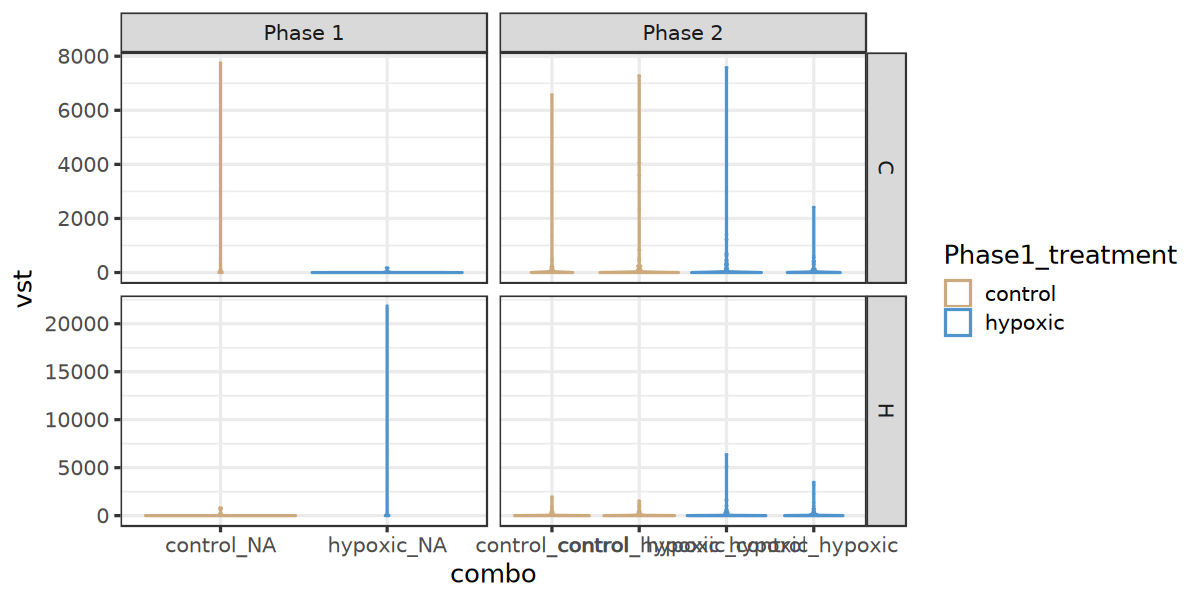

In [55]:
options(repr.plot.height = 5, repr.plot.width = 10)

ggplot(hc_vst_all, aes(x=combo, y = vst, col = Phase1_treatment)) +
facet_grid(DEG_group ~ phase_from, scales = 'free') +
geom_violin() +
scale_color_manual(values = c("hypoxic" = "steelblue3", "control" = "burlywood3")) +
theme_bw(base_size = 15)

there's so much variation in the data (lots of genes with 0 expression, some with vst in the 10's of 1000's) so it's hard to see anything here ... 



plot by gene?? don't love this idea but maybe will be able to spot interesting genes since there's *only* 51 ...

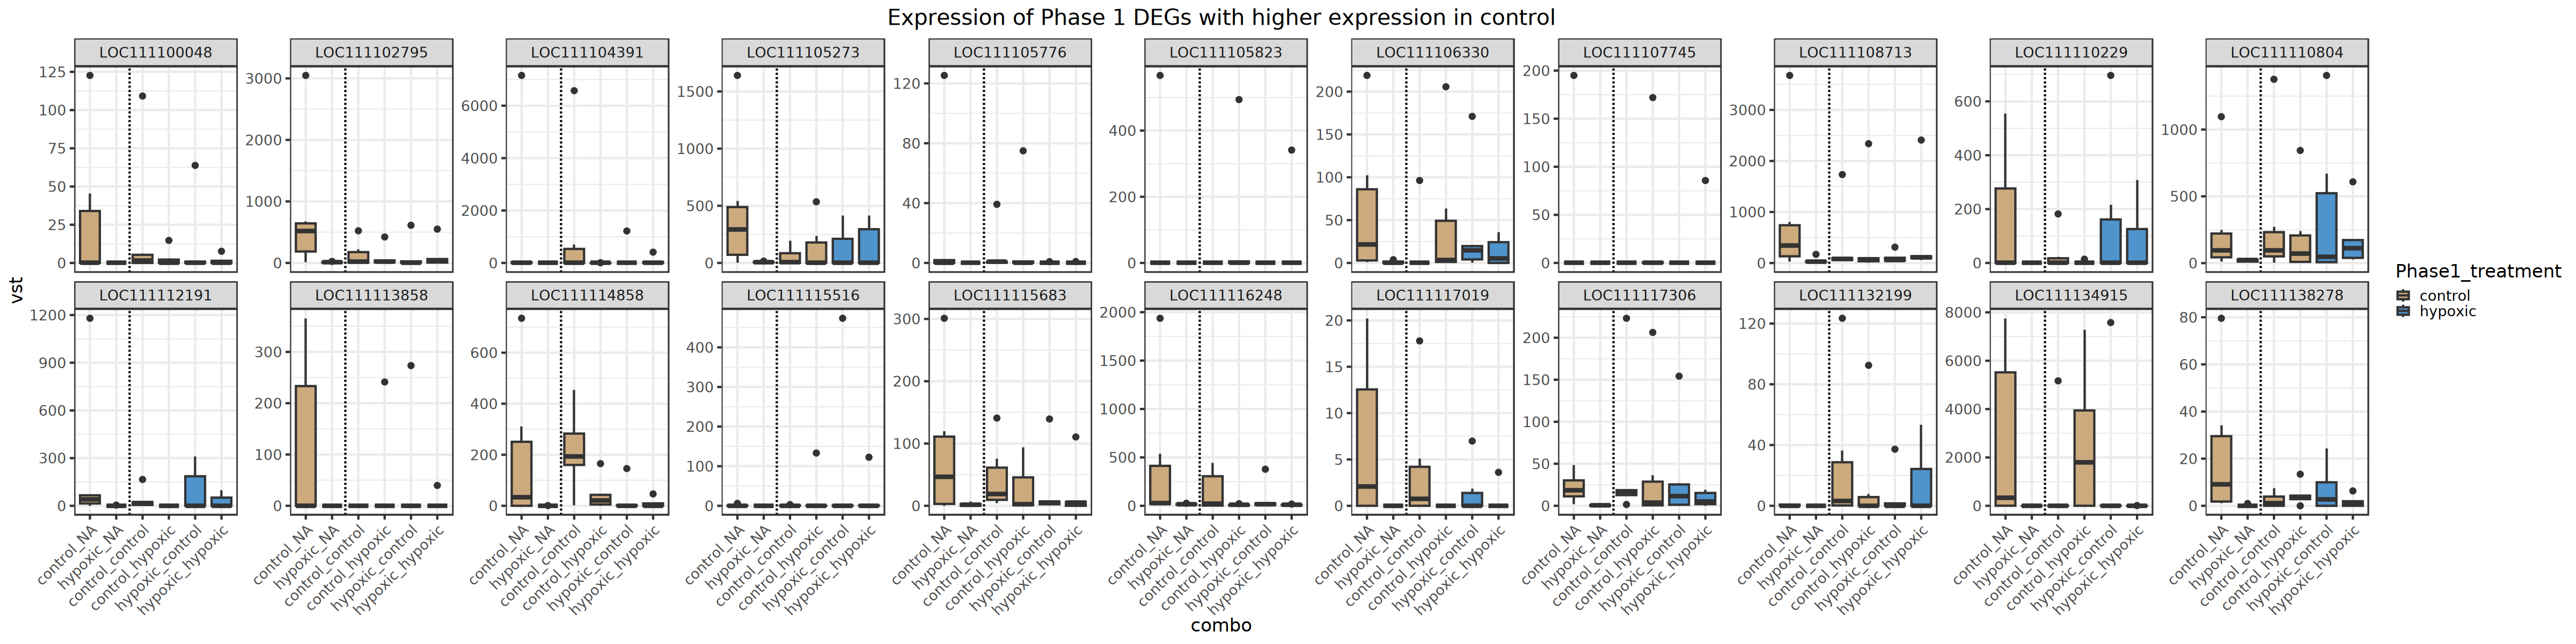

In [76]:
options(repr.plot.width = 40, repr.plot.height = 10)

hc_vst_all$combo <- factor(
  hc_vst_all$combo,
  levels = c("control_NA", "hypoxic_NA", "control_control", "control_hypoxic", "hypoxic_control", "hypoxic_hypoxic")
)

# just DEG with higher expression in control
ggplot(hc_vst_all %>% filter(DEG_group == 'C'), aes(x = combo, y = vst, fill = Phase1_treatment)) +
  geom_boxplot() +
scale_fill_manual(values = c("hypoxic" = "steelblue3", "control" = "burlywood3")) +
  facet_wrap(~ Gene, scales = "free_y", ncol = 11, nrow = 2) + 
# add line
geom_vline(xintercept = 2.5, linetype = 'dashed') +
# labels
labs(title = 'Expression of Phase 1 DEGs with higher expression in control') +
# theme
theme_bw(base_size = 20) +
theme(axis.text.x = element_text(angle = 45, hjust = 1),
     plot.title = element_text(hjust = 0.5))

dashed line separates the phase 1 and phase 2 oysters

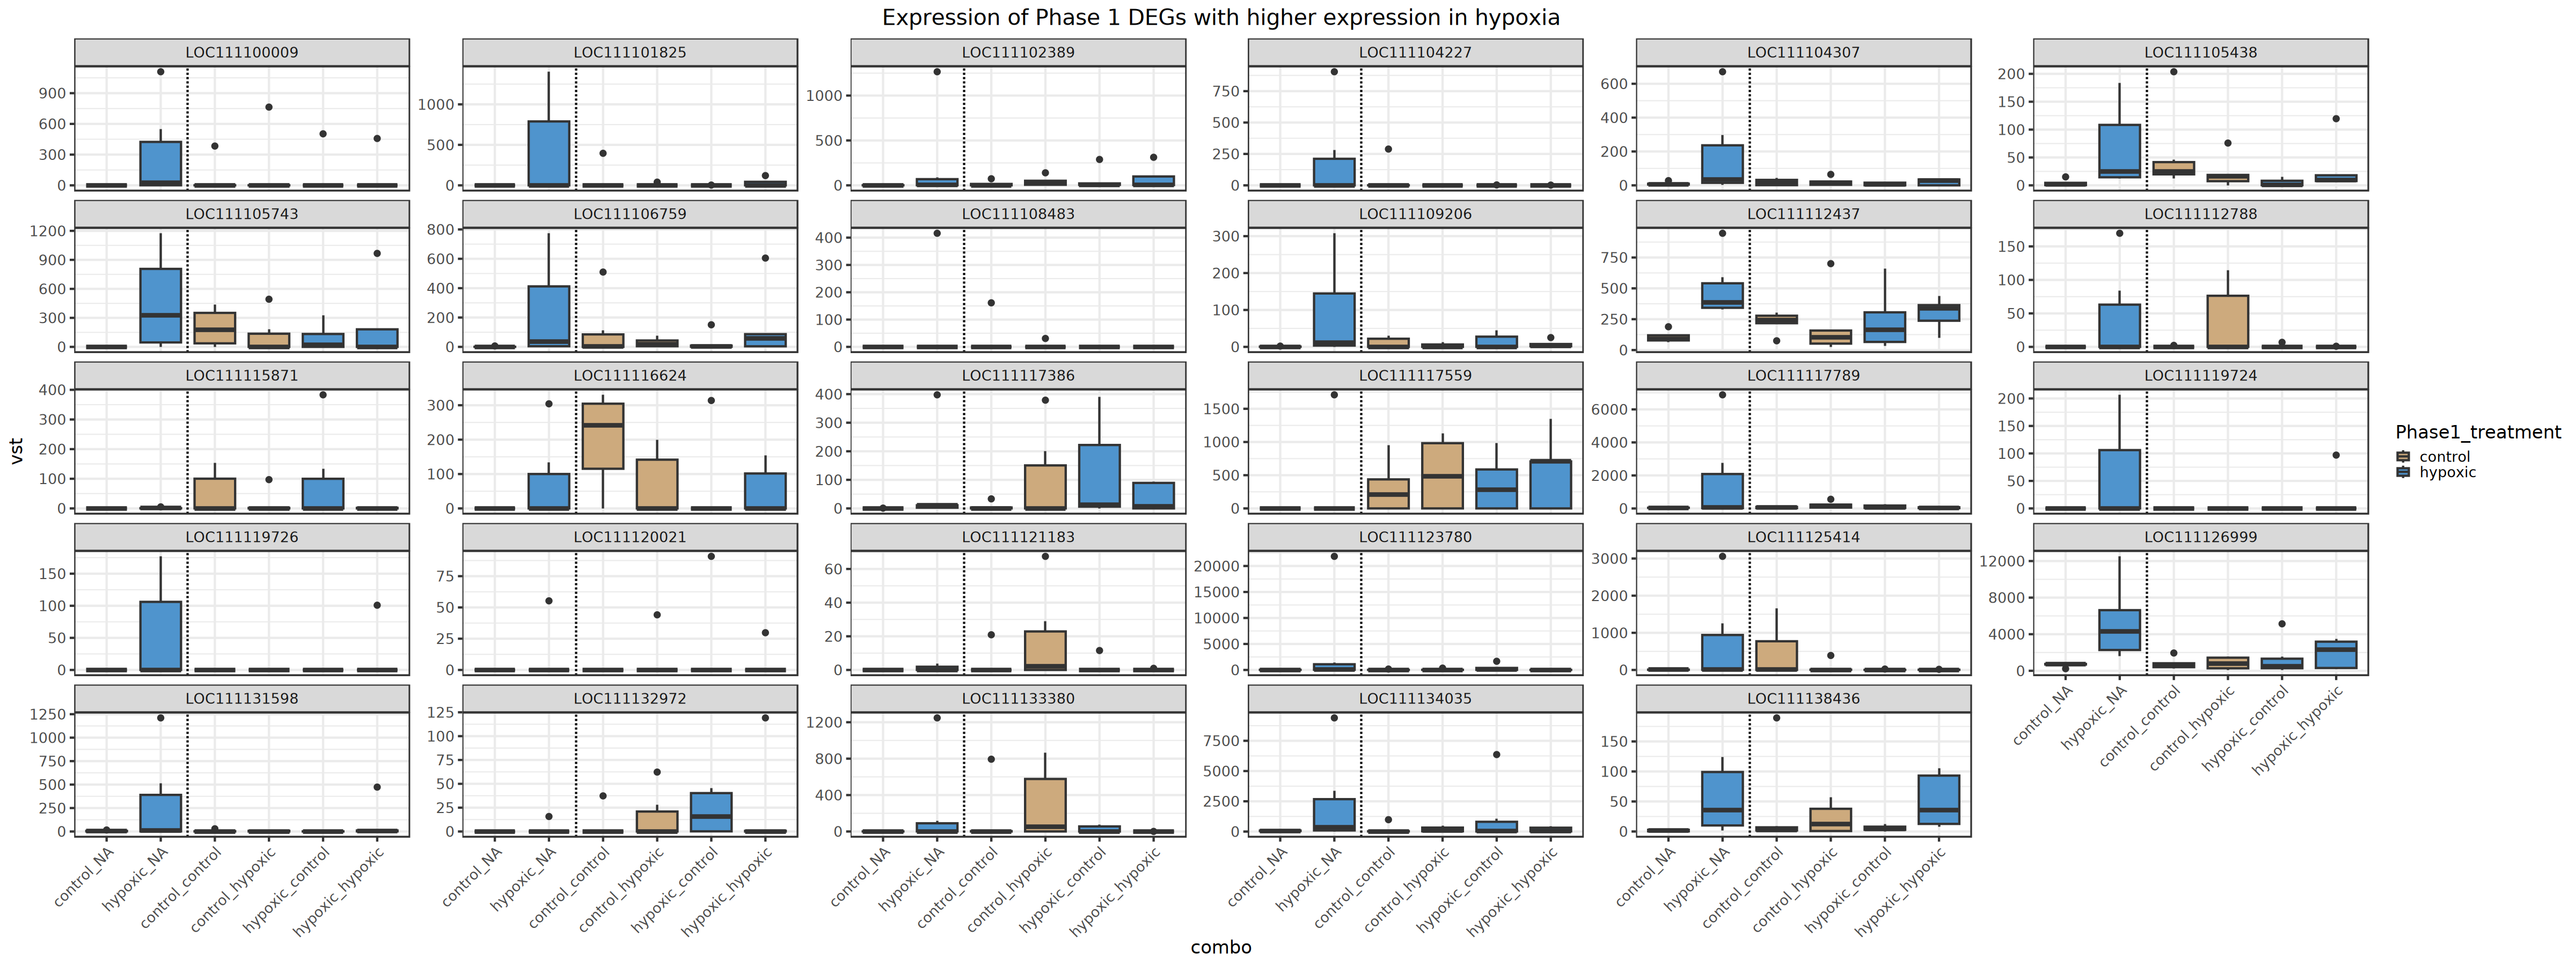

In [75]:
options(repr.plot.width = 40, repr.plot.height = 15)

# just DEG with higher expression in control
ggplot(hc_vst_all %>% filter(DEG_group == 'H'), aes(x = combo, y = vst, fill = Phase1_treatment)) +
  geom_boxplot() +
scale_fill_manual(values = c("hypoxic" = "steelblue3", "control" = "burlywood3")) +
  facet_wrap(~ Gene, scales = "free_y") + 
# add line
geom_vline(xintercept = 2.5, linetype = 'dashed') +
# labels
labs(title = 'Expression of Phase 1 DEGs with higher expression in hypoxia') +
# theme
theme_bw(base_size = 20) +
theme(axis.text.x = element_text(angle = 45, hjust = 1),
     plot.title = element_text(hjust = 0.5))

this is overwhelming lol

what about plotting the means?? (which yes, might be problematic bc you're ignoring a lot of data but whatever, I'll deal with that later)

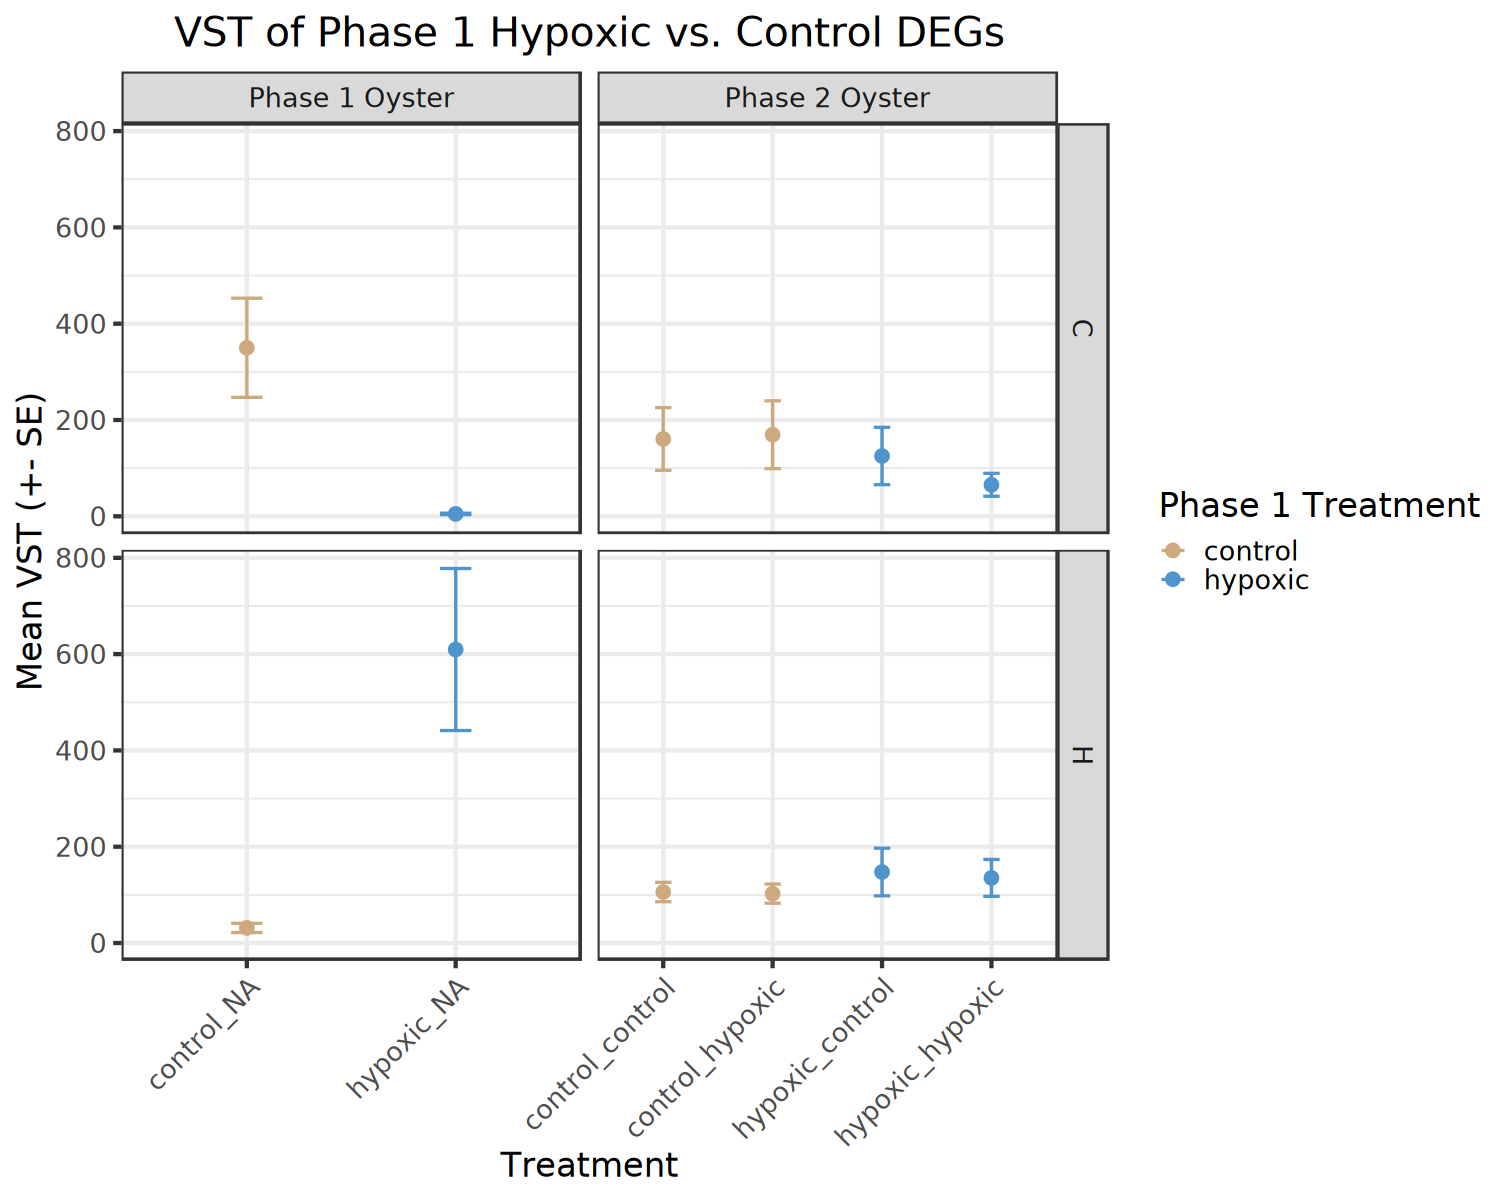

In [52]:
options(repr.plot.height = 10, repr.plot.width = 12.5)

ggplot(hc_vst.mean, aes(x=combo, y=mean_vst, col = Phase1_treatment)) +
# mean points
geom_point() + 

# error bars
## STANDARD ERROR
  geom_errorbar(aes(ymin = mean_vst - se_vst, ymax = mean_vst + se_vst),
                width = 0.15,
                linewidth = 0.7) +
   scale_linetype_manual(
    name = "Phase 1 Treatment",             
    values = c("solid", "dashed")
  ) +

# facet 
facet_grid(DEG_group ~ phase_from, scales = 'free_x') + 

# color
scale_color_manual(values = c("hypoxic" = "steelblue3", "control" = "burlywood3")) +

# labels
labs(x = 'Treatment',
     y = 'Mean VST (+- SE)',
     col = 'Phase 1 Treatment',
    title = 'VST of Phase 1 Hypoxic vs. Control DEGs') + 

# theme
theme_bw(base_size = 20) +
theme(axis.text.x = element_text(angle = 45, hjust = 1),
     plot.title = element_text(hjust = 0.5))

**description of plot**
- columns = phase 1 or phase 2 oyster samples
- rows = DEGs that had higher expression in phase 1 control oysters or phase 1 hypoxic oysters
- colors = phase 1 treatment

Looking first at the top row - **DEGs with higher expression in Phase 1 Control**:
- of the phase 2 oyster samples, those that experienced early control conditions (red) have reduced expression - and it doesn't seem the later exposure influences that? their means are pretty similar
    - so reduced expression over time, but not necessarily due to later life environment? just bc of life?
- phase 2 oyster samples that experienced early hypoxia (blue) have slightly higher expression than the phase 1 oyster samples - although it does appear there is a difference between the later life exposures - later life hypoxia has lower expression of these genes compared to later life control
    - return to control conditions allows for recovery (??) since HC resembles the CC and CH oysters??

Looking at the bottom row - **DEGs with higher expression in Phase 1 Hypoxia**:
- overall reduced expression in the phase 2 oyster samples - **evidence for more plasticity early in life??**
- phase 2 oysters that were first exposed to hypoxia still have higher expression (kinda) than those that were first exposed to control (so still follow pattern from early life, just diminished)
- not a huge difference between phase 2 oysters that shared the same early exposure (all blue or all red)
    - although *slightly* reduced expression in HH compared to HC
 
and maybe this isn't all that surprising bc there's not a ton of overlap with DEGs between phase 1 samples and phase 2 samples (see [DEGs_overlap.ipynb](https://github.com/jgmcdonough/CE24_RNA-seq/blob/main/analysis/diff_expression/DEGs_overlap.ipynb))

I don't loveeee this plot just bc it hides a lot of noise by reducing the data down to one point (mean) - I think instead, to deal with all the noise (see plot before this one) I could calculate the difference in expression between phase 1 and phase 2 oysters that share the same early life exposure (phase 1)

#### calc vst diff
steps:
1. separate phase 1 oysters from phase 2
2. for every gene and oyster, substract the phase 2 vst expression of each oyster from the mean of phase 1 expression (need to think about if there's a better way to do this ...)
    - if difference is **positive**: higher expression in the phase 2 oyster than phase 1 oyster
    - if difference is **negative**: lower expression in phase 2 oyster than phase 1 oyster


In [18]:
head(hc_vst_all)

,Gene,Sample,vst,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep,combo,phase_from,DEG_group
,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>
1,LOC111100009,C2_H1_W04,0.000000,control,ambient,normoxic,2,hypoxic,ambient,hypoxic,1,control_hypoxic,Phase 2,H
2,LOC111100009,C5_C3_W33,0.000000,control,ambient,normoxic,5,control,ambient,normoxic,3,control_control,Phase 2,H
3,LOC111100009,C4_Nu_W29,0.000000,control,ambient,normoxic,4,NA,NA,NA,NA,control_NA,Phase 1,H
4,LOC111100009,C1_Nu_W05,0.000000,control,ambient,normoxic,1,NA,NA,NA,NA,control_NA,Phase 1,H
5,LOC111100009,H4_Nu_B28,1.905578,hypoxic,ambient,hypoxic,4,NA,NA,NA,NA,hypoxic_NA,Phase 1,H
6,LOC111100009,H2_Nu_B14,45.811912,hypoxic,ambient,hypoxic,2,NA,NA,NA,NA,hypoxic_NA,Phase 1,H


instead of long-format, I want the data in wide-format so that each row is a gene and each column is a sample - probably just save the rest of the info as meta??

In [32]:
# convert to wide format
hc_vst.wide <- hc_vst_all[,1:3] %>% 
pivot_wider(id_cols = Gene, # pull row names
            names_from = Sample, # pull column names
            values_from = vst) %>%
column_to_rownames(var = 'Gene') # remove gene column, make rowname

head(hc_vst.wide)

,C2_H1_W04,C5_C3_W33,C4_Nu_W29,C1_Nu_W05,H4_Nu_B28,H2_Nu_B14,C6_H3_W36,H3_H6_B66,C1_H6_W62,C4_H5_W56,⋯,H6_C3_B36,H2_C1_B04,H6_H3_B35,C3_C2_W17,C1_C4_W37,H4_H2_B19,H6_Nu_B45,H1_Nu_B08,H5_C4_B46,C4_C6_W67
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
LOC111100009,0.00000,0.0000000,0.000,0.00000,1.905578,45.811912,0.7347799,0.000000,0.0000,0.00000,⋯,0.000000,0.0000000,457.632143,0.000000,383.651117,0.000000,0.000000,550.08688,503.108482,0.7537474
LOC111100048,0.00000,0.0000000,0.000,0.00000,0.000000,0.000000,2.9391197,0.000000,0.0000,0.00000,⋯,0.000000,0.0000000,1.416818,0.000000,0.000000,0.000000,0.000000,0.00000,1.063654,3.0149897
LOC111101825,0.00000,0.0000000,0.000,0.00000,1402.505506,0.000000,39.6781155,43.635966,0.0000,0.00000,⋯,0.000000,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000,1052.04115,0.000000,0.0000000
LOC111102389,45.94318,0.8489815,0.000,0.00000,1265.303880,5.389637,0.0000000,98.908189,139.7026,19.72903,⋯,6.367917,0.9238021,7.084089,1.867356,73.394127,3.609982,7.868361,0.00000,288.250314,20.3511803
LOC111102795,47.03706,222.4331467,677.962,82.48828,3.811156,25.151638,16.1651582,5.818129,422.4608,18.69066,⋯,31.839584,612.4808105,63.756800,522.859646,3.336097,549.619723,13.113935,9.82298,6.381926,3.0149897
LOC111104227,0.00000,0.0000000,0.000,0.00000,0.000000,0.000000,0.0000000,1.939376,0.0000,0.00000,⋯,0.000000,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000,281.91952,0.000000,0.7537474


get list of sample names for different oyster categories

In [29]:
## pull oyster samples ##

# all phase 1 hypoxic 
p1_hyp <- hc_vst_all %>% 
filter(phase_from == 'Phase 1' & Phase1_treatment == 'hypoxic') %>% 
pull(Sample) %>% 
unique()

# all phase 1 control 
p1_cont <- hc_vst_all %>% 
filter(phase_from == 'Phase 1' & Phase1_treatment == 'control') %>% 
pull(Sample) %>% 
unique()

# all phase 2 oysters that were hypoxic phase 1
p2_hyp <- hc_vst_all %>% 
filter(phase_from == 'Phase 2' & Phase1_treatment == 'hypoxic') %>% 
pull(Sample) %>% 
unique()

# all phase 2 oysters that were control phase 1
p2_cont <- hc_vst_all %>% 
filter(phase_from == 'Phase 2' & Phase1_treatment == 'control') %>% 
pull(Sample) %>% 
unique()

pull these samples from wide vst df

In [35]:
p1_hyp.vst <- hc_vst.wide[,colnames(hc_vst.wide) %in% p1_hyp]
head(p1_hyp.vst)

p1_cont.vst <- hc_vst.wide[,colnames(hc_vst.wide) %in% p1_cont]

p2_hyp.vst <- hc_vst.wide[,colnames(hc_vst.wide) %in% p2_hyp]

p2_cont.vst <- hc_vst.wide[,colnames(hc_vst.wide) %in% p2_cont]

,H4_Nu_B28,H2_Nu_B14,H5_Nu_B35,H3_Nu_B18,H6_Nu_B45,H1_Nu_B08
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
LOC111100009,1.905578,45.811912,1109.164801,0.00000,0.000000,550.08688
LOC111100048,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000
LOC111101825,1402.505506,0.000000,0.000000,0.00000,0.000000,1052.04115
LOC111102389,1265.303880,5.389637,0.000000,89.19347,7.868361,0.00000
LOC111102795,3.811156,25.151638,9.217436,5.09677,13.113935,9.82298
LOC111104227,0.000000,0.000000,904.332889,0.00000,0.000000,281.91952


ah there's SO much variation and I'm not too sure how to handle it... even just in this small snippet, we see that there are some genes that range from 0 to 1000 across the 6 replicate samples